# Лабораторная работа №4: линейная регрессия

Автор: Гроза И.В., группа 6401

Датасет: `winequality-white.csv`  
Целевой признак: `quality`


## Анализ и план

**Цель работы**: сравнить несколько регрессионных моделей для предсказания качества белого вина по физико-химическим признакам.

План выполнения:
1. Загрузить и описать датасет.
2. Выполнить очистку и базовую предобработку.
3. Исследовать связи между признаками и целевой переменной.
4. Обучить модели на численных признаках.
5. Повторить обучение в едином `Pipeline` на том же наборе признаков, так как исходный датасет не содержит категориальных столбцов.
6. Выполнить отбор признаков и сравнить результат с лучшей моделью второго этапа.

Замечание: исходный датасет `winequality-white.csv` содержит только численные признаки. Согласно примечанию в задании, шаги, связанные с временным удалением и последующим кодированием категориальных признаков, для такого датасета пропускаются.


## Подготовка окружения

Импортируем библиотеки, задаём `random_state` и параметры визуализации.


In [31]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFECV, SelectKBest, SequentialFeatureSelector, f_regression
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

SEED = 42
TEST_SIZE = 0.25
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)


## Загрузка датасета

Источник данных: локальный файл `../data/winequality-white.csv`.  
Оригинальный набор данных: Wine Quality, UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/186/wine+quality.


In [32]:
dataset_path = "../data/winequality-white.csv"
target_col = "quality"

raw_df = pd.read_csv(dataset_path, sep=";")

print(f"Dataset path: {dataset_path}")
print(f"Shape before cleaning: {raw_df.shape}")
display(raw_df.head())
raw_df.info()


Dataset path: ../data/winequality-white.csv
Shape before cleaning: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


## Описание признаков датасета

Ниже приведено краткое описание признаков, единиц измерения и целевой переменной.


In [33]:
feature_description_df = pd.DataFrame(
    [
        {"feature": "fixed_acidity", "description": "фиксированная кислотность", "unit": "не указано в источнике"},
        {"feature": "volatile_acidity", "description": "летучая кислотность", "unit": "не указано в источнике"},
        {"feature": "citric_acid", "description": "содержание лимонной кислоты", "unit": "не указано в источнике"},
        {"feature": "residual_sugar", "description": "остаточный сахар", "unit": "г/дм^3"},
        {"feature": "chlorides", "description": "содержание хлоридов", "unit": "г/дм^3"},
        {"feature": "free_sulfur_dioxide", "description": "свободный диоксид серы", "unit": "мг/дм^3"},
        {"feature": "total_sulfur_dioxide", "description": "общий диоксид серы", "unit": "мг/дм^3"},
        {"feature": "density", "description": "плотность вина", "unit": "г/см^3"},
        {"feature": "pH", "description": "кислотность по шкале pH", "unit": "безразмерная"},
        {"feature": "sulphates", "description": "содержание сульфатов", "unit": "г/дм^3"},
        {"feature": "alcohol", "description": "содержание алкоголя", "unit": "% об."},
        {"feature": "quality", "description": "оценка качества вина", "unit": "балл"},
    ]
)

display(feature_description_df)


,feature,description,unit
0,fixed_acidity,фиксированная кислотность,не указано в источнике
1,volatile_acidity,летучая кислотность,не указано в источнике
2,citric_acid,содержание лимонной кислоты,не указано в источнике
3,residual_sugar,остаточный сахар,г/дм^3
4,chlorides,содержание хлоридов,г/дм^3
5,free_sulfur_dioxide,свободный диоксид серы,мг/дм^3
6,total_sulfur_dioxide,общий диоксид серы,мг/дм^3
7,density,плотность вина,г/см^3
8,pH,кислотность по шкале pH,безразмерная
9,sulphates,содержание сульфатов,г/дм^3


## Предобработка данных

На этом шаге:
- переименуем столбцы в `snake_case`;
- удалим дубликаты;
- проверим пропуски;
- зафиксируем, что в исходном датасете отсутствуют категориальные признаки.


In [34]:
df = raw_df.copy()
df.columns = df.columns.str.replace(" ", "_")

duplicate_count = int(df.duplicated().sum())
missing_summary = df.isna().sum().sort_values(ascending=False)

df = df.drop_duplicates().reset_index(drop=True)

print(f"Rows after duplicate removal: {df.shape[0]}")
print(f"Removed duplicates: {duplicate_count}")
if (missing_summary > 0).any():
    display(missing_summary[missing_summary > 0])
else:
    print("Missing values were not found.")

print("Categorical columns in the source dataset: none")
display(df.head())


Rows after duplicate removal: 3961
Removed duplicates: 937
Missing values were not found.
Categorical columns in the source dataset: none


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


## Матрица корреляций

Построим `heatmap` по численным признакам, включая целевую переменную.


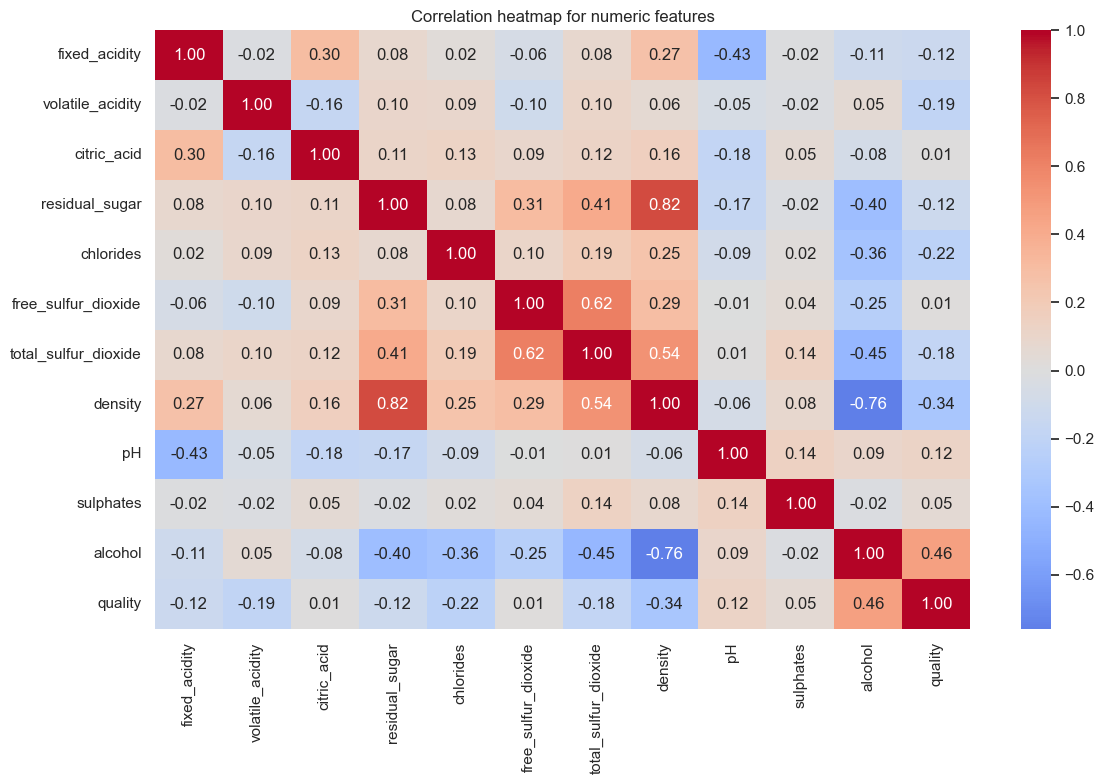

In [35]:
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation heatmap for numeric features")
plt.tight_layout()
plt.show()


## Взаимосвязь `quality` с каждым численным признаком

Используем `FacetGrid` и `regplot`, чтобы по отдельности посмотреть связь целевой переменной с каждым признаком.


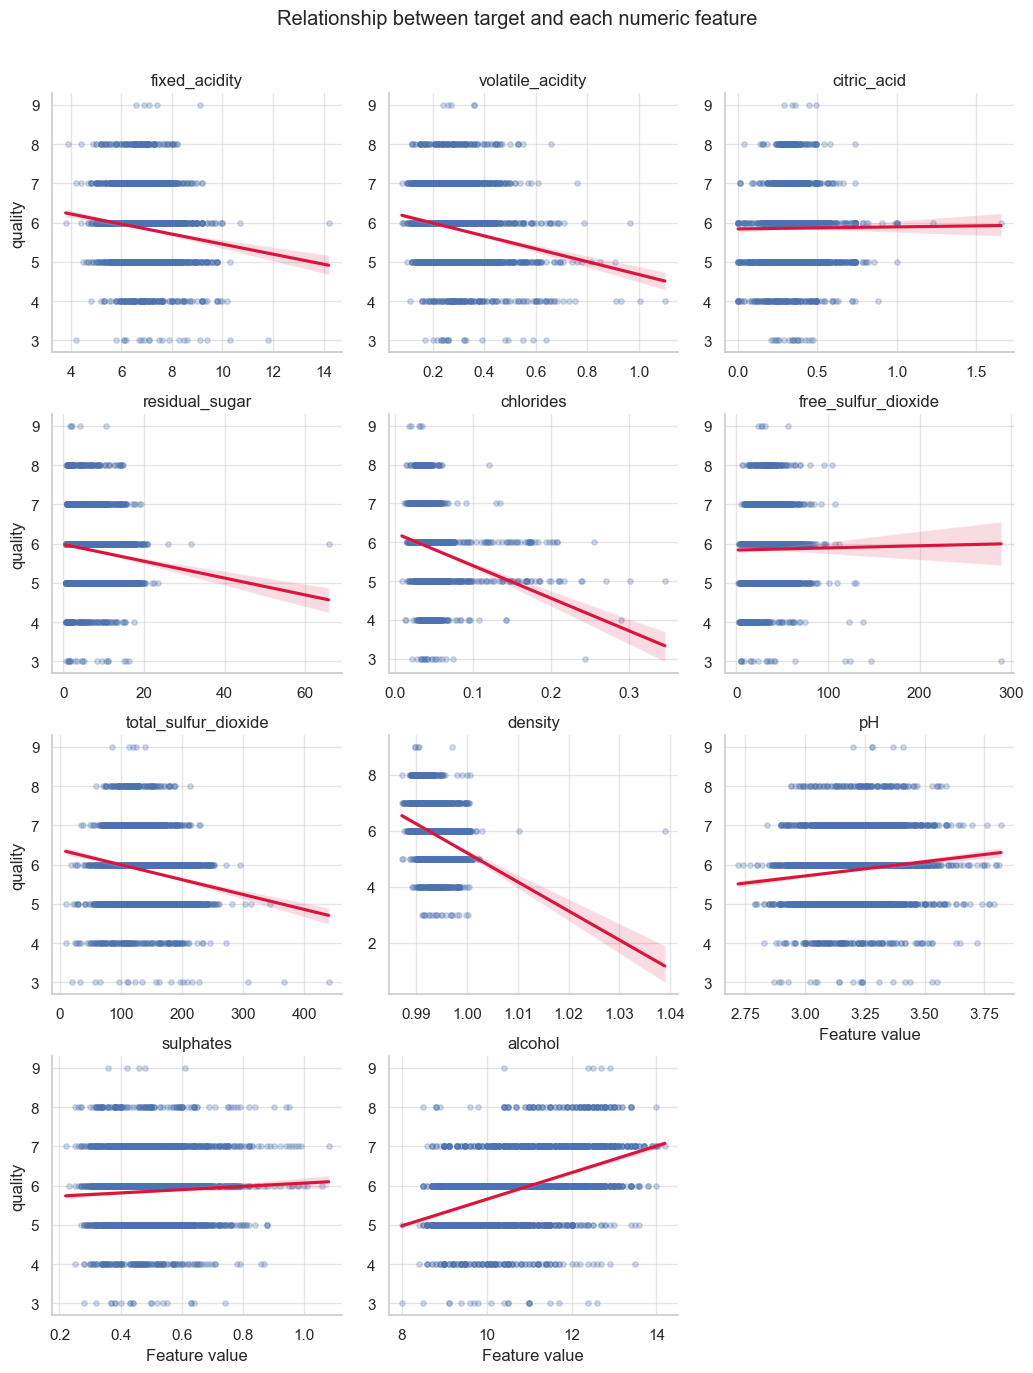

In [36]:
plot_features = [column for column in numeric_df.columns if column != target_col]
long_df = df[[target_col] + plot_features].melt(
    id_vars=target_col,
    value_vars=plot_features,
    var_name="feature",
    value_name="value",
)

facet_grid = sns.FacetGrid(
    long_df,
    col="feature",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=3.5,
)
facet_grid.map_dataframe(
    sns.regplot,
    x="value",
    y=target_col,
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "crimson"},
)
facet_grid.set_axis_labels("Feature value", "quality")
facet_grid.set_titles("{col_name}")
plt.subplots_adjust(top=0.92)
facet_grid.fig.suptitle("Relationship between target and each numeric feature")
plt.show()


## Разбиение выборки и нормализация численных признаков

Делим выборку на обучающую и тестовую. Поскольку в выбранном датасете категориальные признаки отсутствуют, полный набор признаков совпадает с численным набором, а нормализация выполняется только для численных колонок.


In [37]:
feature_cols = [column for column in df.columns if column != target_col]
categorical_cols = []
numeric_cols = feature_cols.copy()

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
)

X_train_num = X_train_full[numeric_cols].copy()
X_test_num = X_test_full[numeric_cols].copy()

scaler_stage1 = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler_stage1.fit_transform(X_train_num),
    columns=numeric_cols,
    index=X_train_num.index,
)
X_test_num_scaled = pd.DataFrame(
    scaler_stage1.transform(X_test_num),
    columns=numeric_cols,
    index=X_test_num.index,
)

print(f"Train shape full: {X_train_full.shape}")
print(f"Test shape full: {X_test_full.shape}")
print(f"Train shape numeric: {X_train_num_scaled.shape}")
print(f"Test shape numeric: {X_test_num_scaled.shape}")
display(X_train_full.head())


Train shape full: (2970, 11)
Test shape full: (991, 11)
Train shape numeric: (2970, 11)
Test shape numeric: (991, 11)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
3726,7.5,0.305,0.38,1.4,0.047,30.0,95.0,0.99158,3.22,0.52,11.5
2413,7.7,0.250,0.30,7.8,0.038,67.0,196.0,0.99555,3.10,0.50,10.1
31,6.5,0.390,0.23,5.4,0.051,25.0,149.0,0.99340,3.24,0.35,10.0
2159,7.5,0.250,0.32,8.2,0.024,53.0,209.0,0.99563,3.12,0.46,10.8
3084,5.5,0.240,0.45,1.7,0.046,22.0,113.0,0.99224,3.22,0.48,10.0


## Вспомогательные функции

Подготовим общие функции для расчёта метрик, извлечения коэффициентов и построения графиков важности признаков.


In [38]:
def calculate_metrics(y_true, y_pred) -> dict[str, float]:
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def clean_feature_names(feature_names) -> list[str]:
    cleaned_names = []
    for name in feature_names:
        cleaned_name = (
            str(name)
            .replace("num__", "")
            .replace("cat__", "")
            .replace("remainder__", "")
        )
        cleaned_names.append(cleaned_name)
    return cleaned_names


def extract_final_estimator(model):
    if isinstance(model, Pipeline):
        return model.named_steps["model"]
    return model


def fit_search_or_model(estimator, param_grid, X_train, y_train):
    if param_grid:
        search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=CV,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        return search.best_estimator_, search.best_params_, search

    estimator.fit(X_train, y_train)
    return estimator, {}, estimator


def coefficient_table(model, feature_names):
    final_estimator = extract_final_estimator(model)
    if not hasattr(final_estimator, "coef_"):
        return None

    coefficient_values = np.ravel(final_estimator.coef_)
    table = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficient_values,
            "abs_coefficient": np.abs(coefficient_values),
        }
    ).sort_values("abs_coefficient", ascending=False)
    return table


def build_importance_table(model, X_ref, y_ref, feature_names):
    final_estimator = extract_final_estimator(model)

    if hasattr(final_estimator, "coef_"):
        importance_values = np.abs(np.ravel(final_estimator.coef_))
        importance_label = "abs(coef_)"
    elif hasattr(final_estimator, "feature_importances_"):
        importance_values = np.ravel(final_estimator.feature_importances_)
        importance_label = "feature_importance"
    else:
        permutation = permutation_importance(
            model,
            X_ref,
            y_ref,
            n_repeats=10,
            random_state=SEED,
            scoring="r2",
            n_jobs=-1,
        )
        importance_values = permutation.importances_mean
        importance_label = "permutation_importance"

    table = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importance_values,
        }
    ).sort_values("importance", ascending=False)
    return table, importance_label


def plot_importance(model_name, model, X_ref, y_ref, feature_names, top_n=15):
    importance_table, importance_label = build_importance_table(model, X_ref, y_ref, feature_names)
    plot_df = importance_table.head(top_n).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, max(4, len(plot_df) * 0.35)))
    plt.barh(plot_df["feature"], plot_df["importance"], color="steelblue")
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"{model_name}: ranked feature importance")
    plt.tight_layout()
    plt.show()

    return importance_table


def report_model(name, model, X_test, y_test, feature_names, best_params=None):
    predictions = model.predict(X_test)
    metrics = calculate_metrics(y_test, predictions)

    final_estimator = extract_final_estimator(model)
    coef_tbl = coefficient_table(model, feature_names)

    print(name)
    print(f"Лучшие параметры: {best_params or {}}")
    if hasattr(final_estimator, "intercept_"):
        print(f"Свободный коэффициент: {float(np.ravel([final_estimator.intercept_])[0]):.6f}")
    else:
        print("Свободный коэффициент для этой модели не рассчитывается")
    if coef_tbl is not None:
        display(coef_tbl.head(10))
    else:
        print("Коэффициенты для этой модели не рассчитываются")

    importance_tbl = plot_importance(name, model, X_test, y_test, feature_names)
    result_row = {
        "model": name,
        "best_params": best_params or {},
        **metrics,
    }
    return result_row, coef_tbl, importance_tbl


## Этап 1. Линейная регрессия `LinearRegression`

Обучим базовую модель МНК на выборке без категориальных признаков.


LinearRegression
Лучшие параметры: {}
Свободный коэффициент: 5.855556


,feature,coefficient,abs_coefficient
7,density,-0.311372,0.311372
10,alcohol,0.308821,0.308821
3,residual_sugar,0.278457,0.278457
1,volatile_acidity,-0.177294,0.177294
5,free_sulfur_dioxide,0.102865,0.102865
8,pH,0.098949,0.098949
9,sulphates,0.070429,0.070429
2,citric_acid,0.034527,0.034527
6,total_sulfur_dioxide,-0.030958,0.030958
0,fixed_acidity,0.023213,0.023213


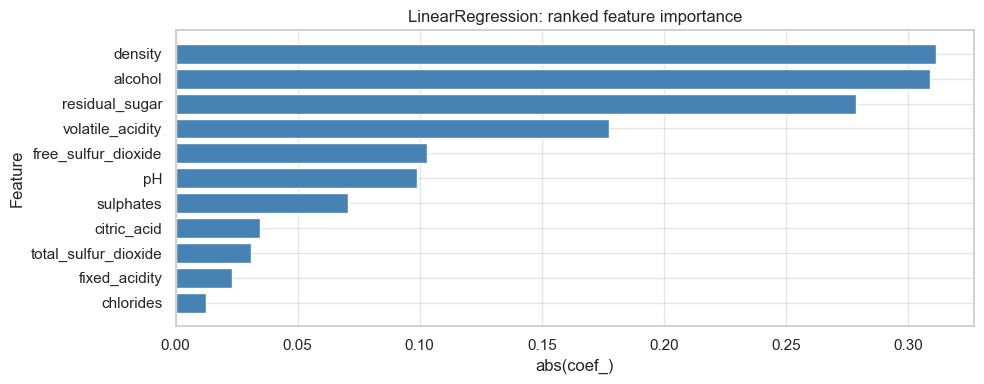

In [39]:
stage1_reports = {}
stage1_results = []

linear_stage1 = LinearRegression()
linear_stage1.fit(X_train_num_scaled, y_train)

linear_result, linear_coef_table, linear_importance_table = report_model(
    name="LinearRegression",
    model=linear_stage1,
    X_test=X_test_num_scaled,
    y_test=y_test,
    feature_names=numeric_cols,
)

stage1_reports["LinearRegression"] = {
    "model": linear_stage1,
    "coef_table": linear_coef_table,
    "importance_table": linear_importance_table,
    "best_params": {},
}
stage1_results.append(linear_result)


## Этап 1. Подбор гиперпараметров для остальных моделей

С помощью `GridSearchCV` подберём параметры для:
- `Ridge`
- `Lasso`
- `ElasticNet`
- `KNeighborsRegressor`
- `DecisionTreeRegressor`


Ridge
Лучшие параметры: {'alpha': np.float64(100.0)}
Свободный коэффициент: 5.855556


,feature,coefficient,abs_coefficient
10,alcohol,0.343913,0.343913
7,density,-0.191852,0.191852
3,residual_sugar,0.187909,0.187909
1,volatile_acidity,-0.172395,0.172395
5,free_sulfur_dioxide,0.104688,0.104688
8,pH,0.072923,0.072923
9,sulphates,0.061737,0.061737
6,total_sulfur_dioxide,-0.036667,0.036667
2,citric_acid,0.033587,0.033587
4,chlorides,-0.023175,0.023175


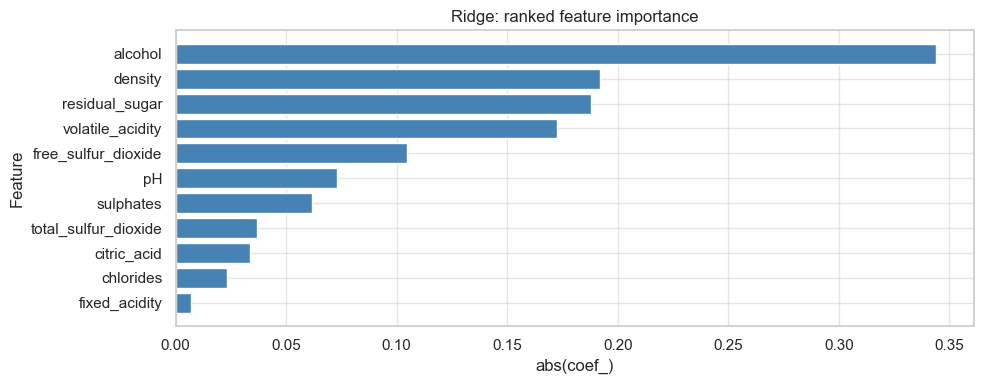

Lasso
Лучшие параметры: {'alpha': np.float64(0.003727593720314938)}
Свободный коэффициент: 5.855556


,feature,coefficient,abs_coefficient
10,alcohol,0.351985,0.351985
7,density,-0.211706,0.211706
3,residual_sugar,0.207595,0.207595
1,volatile_acidity,-0.178939,0.178939
5,free_sulfur_dioxide,0.098127,0.098127
8,pH,0.075611,0.075611
9,sulphates,0.060596,0.060596
2,citric_acid,0.028294,0.028294
6,total_sulfur_dioxide,-0.024732,0.024732
4,chlorides,-0.014254,0.014254


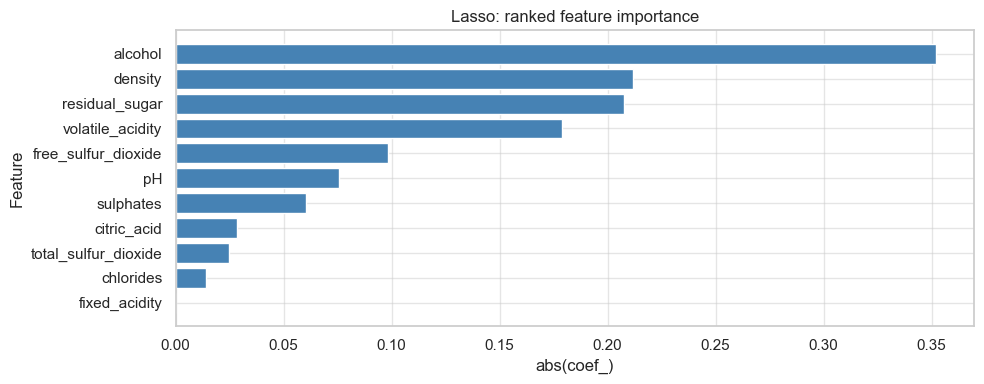

ElasticNet
Лучшие параметры: {'alpha': np.float64(0.00630957344480193), 'l1_ratio': 0.7}
Свободный коэффициент: 5.855556


,feature,coefficient,abs_coefficient
10,alcohol,0.356458,0.356458
7,density,-0.198681,0.198681
3,residual_sugar,0.197171,0.197171
1,volatile_acidity,-0.178530,0.178530
5,free_sulfur_dioxide,0.097506,0.097506
8,pH,0.073345,0.073345
9,sulphates,0.058931,0.058931
2,citric_acid,0.026629,0.026629
6,total_sulfur_dioxide,-0.023855,0.023855
4,chlorides,-0.014503,0.014503


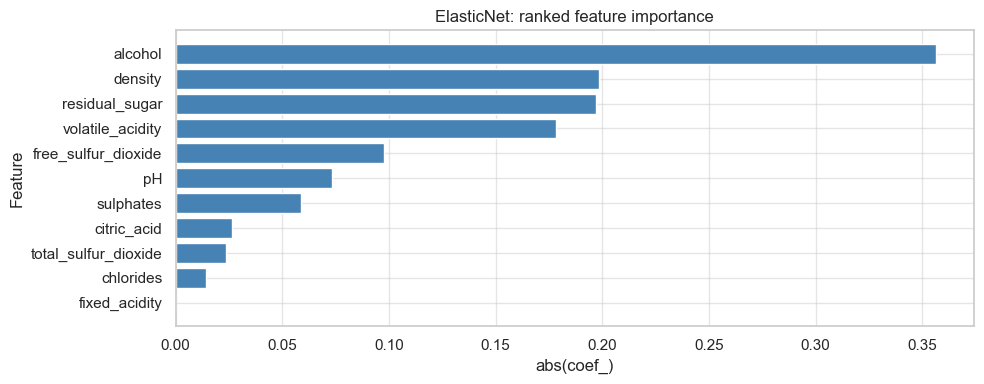

KNeighborsRegressor
Лучшие параметры: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Свободный коэффициент для этой модели не рассчитывается
Коэффициенты для этой модели не рассчитываются


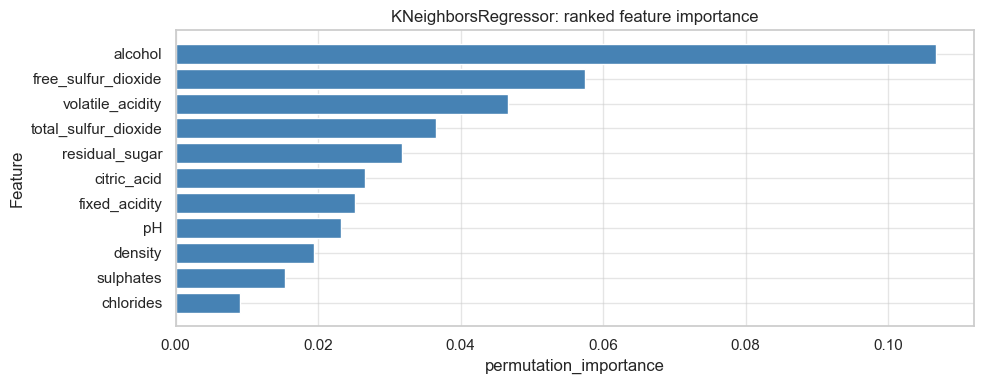

DecisionTreeRegressor
Лучшие параметры: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Свободный коэффициент для этой модели не рассчитывается
Коэффициенты для этой модели не рассчитываются


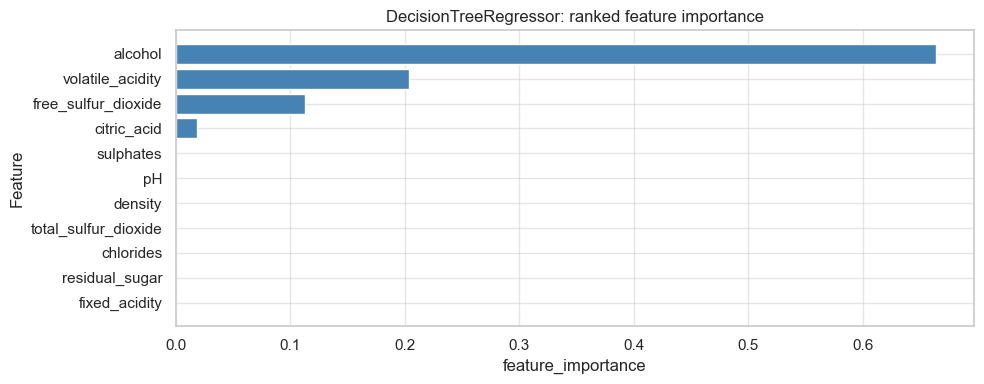

In [40]:
stage1_model_specs = {
    "Ridge": {
        "estimator": Ridge(),
        "param_grid": {"alpha": np.logspace(-3, 2, 8)},
    },
    "Lasso": {
        "estimator": Lasso(max_iter=20000),
        "param_grid": {"alpha": np.logspace(-3, 1, 8)},
    },
    "ElasticNet": {
        "estimator": ElasticNet(max_iter=20000),
        "param_grid": {
            "alpha": np.logspace(-3, 1, 6),
            "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        },
    },
    "KNeighborsRegressor": {
        "estimator": KNeighborsRegressor(),
        "param_grid": {
            "n_neighbors": [3, 5, 7, 9, 11, 15],
            "weights": ["uniform", "distance"],
            "p": [1, 2],
        },
    },
    "DecisionTreeRegressor": {
        "estimator": DecisionTreeRegressor(random_state=SEED),
        "param_grid": {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_leaf": [1, 2, 4, 8],
            "min_samples_split": [2, 5, 10],
        },
    },
}

for model_name, spec in stage1_model_specs.items():
    best_model, best_params, fitted_object = fit_search_or_model(
        estimator=spec["estimator"],
        param_grid=spec["param_grid"],
        X_train=X_train_num_scaled,
        y_train=y_train,
    )

    result_row, coef_tbl, importance_tbl = report_model(
        name=model_name,
        model=best_model,
        X_test=X_test_num_scaled,
        y_test=y_test,
        feature_names=numeric_cols,
        best_params=best_params,
    )

    stage1_reports[model_name] = {
        "model": best_model,
        "coef_table": coef_tbl,
        "importance_table": importance_tbl,
        "best_params": best_params,
        "fitted_object": fitted_object,
    }
    stage1_results.append(result_row)


## Этап 1. Сводные результаты

Сравним модели без категориальных признаков и выберем лучшую.


In [41]:
stage1_results_df = pd.DataFrame(stage1_results).sort_values(
    by=["R2", "MSE", "MAE"],
    ascending=[False, True, True],
).reset_index(drop=True)

display(stage1_results_df)

best_stage1 = stage1_results_df.iloc[0].to_dict()
print(
    f"Лучшая модель первого этапа: {best_stage1['model']} "
    f"(MSE={best_stage1['MSE']:.4f}, MAE={best_stage1['MAE']:.4f}, R2={best_stage1['R2']:.4f})"
)


,model,best_params,MSE,MAE,R2
0,KNeighborsRegressor,"{'n_neighbors': 15, 'p': 1, 'weights': 'distan...",0.533694,0.565603,0.324093
1,LinearRegression,{},0.577994,0.588008,0.267988
2,Lasso,{'alpha': 0.003727593720314938},0.581120,0.589862,0.264030
3,ElasticNet,"{'alpha': 0.00630957344480193, 'l1_ratio': 0.7}",0.581505,0.590124,0.263541
4,Ridge,{'alpha': 100.0},0.581614,0.590070,0.263403
5,DecisionTreeRegressor,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.600755,0.613714,0.239162


Лучшая модель первого этапа: KNeighborsRegressor (MSE=0.5337, MAE=0.5656, R2=0.3241)


## Этап 2. Повторное обучение в едином `Pipeline`

В исходном датасете нет категориальных признаков, поэтому кодирование на этом этапе не требуется. На втором этапе повторим обучение тех же моделей в едином `Pipeline`, где предобработка состоит только из масштабирования численных признаков.


LinearRegression
Лучшие параметры: {}
Свободный коэффициент: 5.855556


,feature,coefficient,abs_coefficient
7,density,-0.311372,0.311372
10,alcohol,0.308821,0.308821
3,residual_sugar,0.278457,0.278457
1,volatile_acidity,-0.177294,0.177294
5,free_sulfur_dioxide,0.102865,0.102865
8,pH,0.098949,0.098949
9,sulphates,0.070429,0.070429
2,citric_acid,0.034527,0.034527
6,total_sulfur_dioxide,-0.030958,0.030958
0,fixed_acidity,0.023213,0.023213


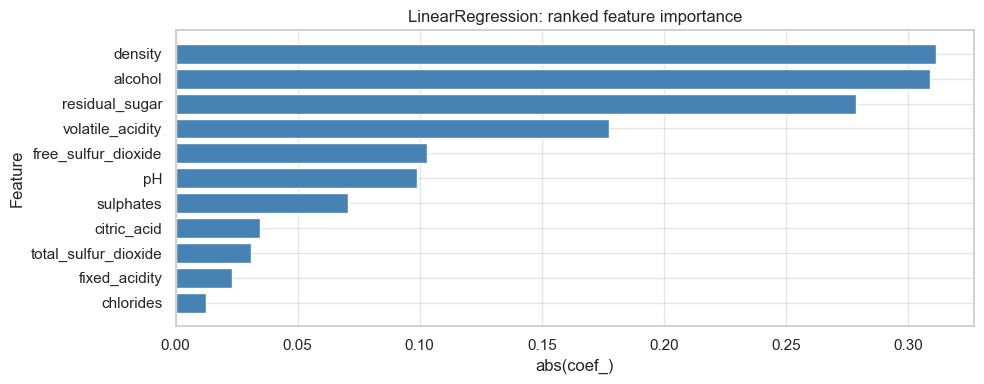

Ridge
Лучшие параметры: {'alpha': np.float64(100.0)}
Свободный коэффициент: 5.855556


,feature,coefficient,abs_coefficient
10,alcohol,0.343913,0.343913
7,density,-0.191852,0.191852
3,residual_sugar,0.187909,0.187909
1,volatile_acidity,-0.172395,0.172395
5,free_sulfur_dioxide,0.104688,0.104688
8,pH,0.072923,0.072923
9,sulphates,0.061737,0.061737
6,total_sulfur_dioxide,-0.036667,0.036667
2,citric_acid,0.033587,0.033587
4,chlorides,-0.023175,0.023175


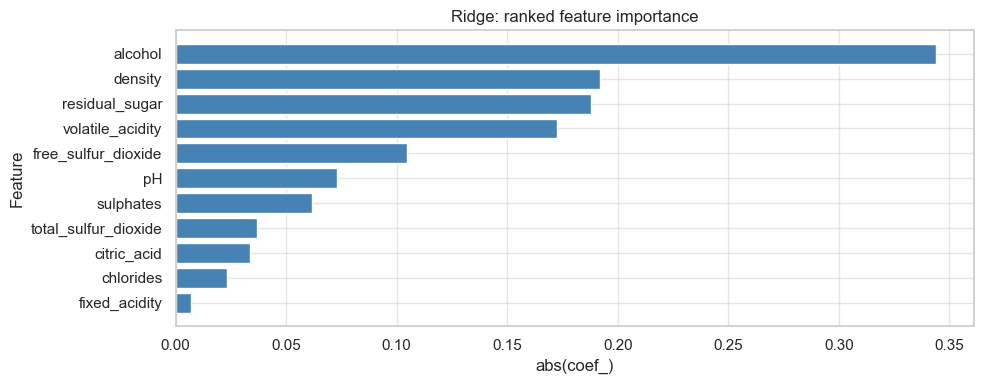

Lasso
Лучшие параметры: {'alpha': np.float64(0.003727593720314938)}
Свободный коэффициент: 5.855556


,feature,coefficient,abs_coefficient
10,alcohol,0.351985,0.351985
7,density,-0.211706,0.211706
3,residual_sugar,0.207595,0.207595
1,volatile_acidity,-0.178939,0.178939
5,free_sulfur_dioxide,0.098127,0.098127
8,pH,0.075611,0.075611
9,sulphates,0.060596,0.060596
2,citric_acid,0.028294,0.028294
6,total_sulfur_dioxide,-0.024732,0.024732
4,chlorides,-0.014254,0.014254


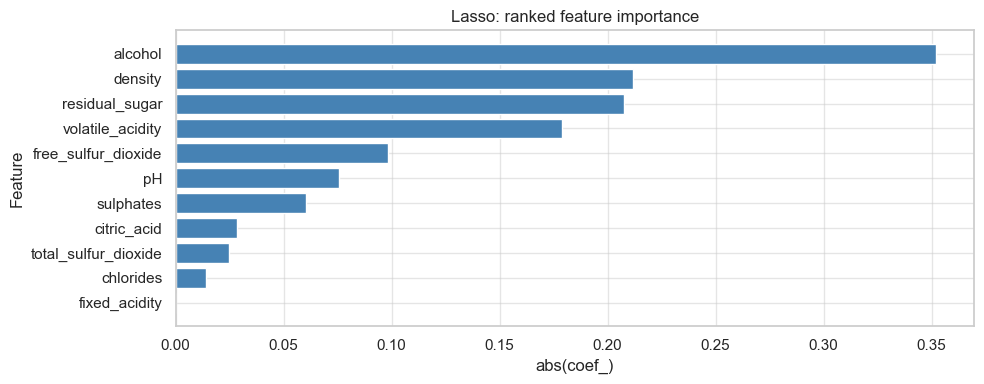

ElasticNet
Лучшие параметры: {'alpha': np.float64(0.00630957344480193), 'l1_ratio': 0.7}
Свободный коэффициент: 5.855556


,feature,coefficient,abs_coefficient
10,alcohol,0.356458,0.356458
7,density,-0.198681,0.198681
3,residual_sugar,0.197171,0.197171
1,volatile_acidity,-0.178530,0.178530
5,free_sulfur_dioxide,0.097506,0.097506
8,pH,0.073345,0.073345
9,sulphates,0.058931,0.058931
2,citric_acid,0.026629,0.026629
6,total_sulfur_dioxide,-0.023855,0.023855
4,chlorides,-0.014503,0.014503


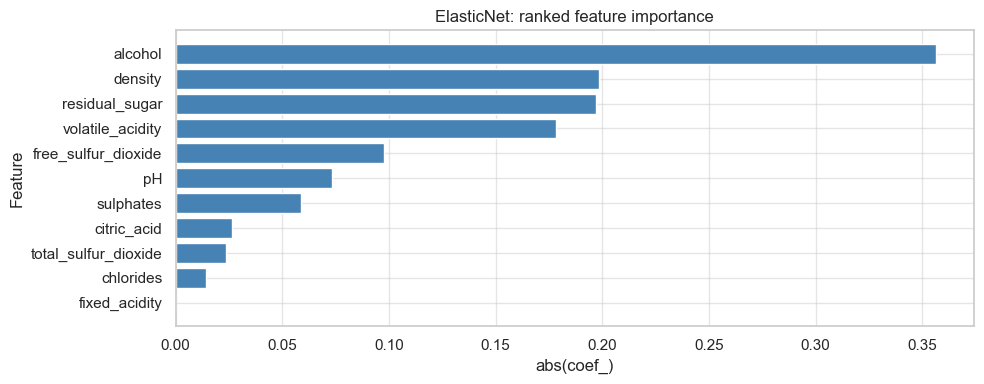

KNeighborsRegressor
Лучшие параметры: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Свободный коэффициент для этой модели не рассчитывается
Коэффициенты для этой модели не рассчитываются


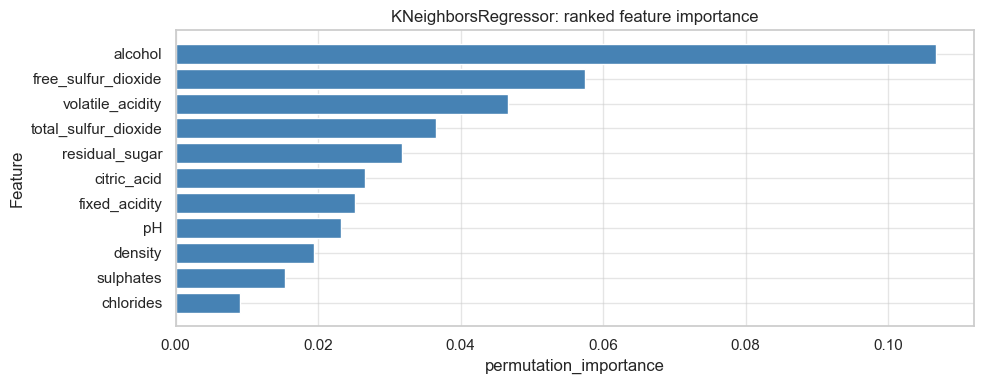

DecisionTreeRegressor
Лучшие параметры: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Свободный коэффициент для этой модели не рассчитывается
Коэффициенты для этой модели не рассчитываются


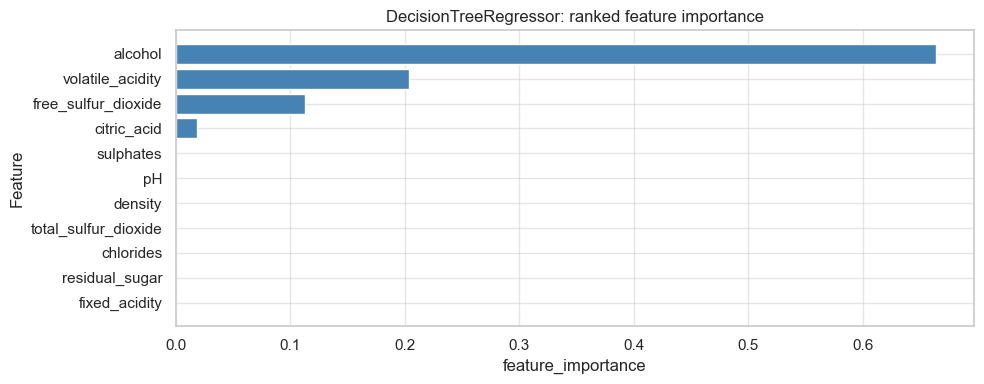

In [42]:
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
        ],
        remainder="drop",
    )


def clone_estimator_with_best_params(model_name):
    if model_name == "LinearRegression":
        return LinearRegression(), {}

    base_estimator = stage1_model_specs[model_name]["estimator"]
    best_params = stage1_reports[model_name]["best_params"]
    estimator = base_estimator.__class__(**base_estimator.get_params())
    estimator.set_params(**best_params)
    return estimator, best_params


stage2_reports = {}
stage2_results = []
stage2_model_names = [
    "LinearRegression",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "KNeighborsRegressor",
    "DecisionTreeRegressor",
]

for model_name in stage2_model_names:
    estimator, best_params = clone_estimator_with_best_params(model_name)
    pipeline = Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", estimator),
        ]
    )
    pipeline.fit(X_train_full, y_train)

    transformed_feature_names = clean_feature_names(
        pipeline.named_steps["preprocessor"].get_feature_names_out()
    )
    result_row, coef_tbl, importance_tbl = report_model(
        name=model_name,
        model=pipeline,
        X_test=X_test_full,
        y_test=y_test,
        feature_names=transformed_feature_names,
        best_params=best_params,
    )

    stage2_reports[model_name] = {
        "pipeline": pipeline,
        "coef_table": coef_tbl,
        "importance_table": importance_tbl,
        "feature_names": transformed_feature_names,
        "best_params": best_params,
    }
    stage2_results.append(result_row)


## Этап 2. Сравнение метрик между этапами

Поскольку `winequality-white.csv` не содержит категориальных признаков, метрики первого и второго этапов должны совпасть или отличаться только из-за технических деталей реализации. Сравнение ниже показывает, что переход к единому `Pipeline` сам по себе не меняет содержательно набор признаков.


In [43]:
stage2_results_df = pd.DataFrame(stage2_results).sort_values(
    by=["R2", "MSE", "MAE"],
    ascending=[False, True, True],
).reset_index(drop=True)

comparison_df = stage1_results_df[["model", "MSE", "MAE", "R2"]].merge(
    stage2_results_df[["model", "MSE", "MAE", "R2"]],
    on="model",
    suffixes=("_without_cat", "_with_cat"),
)
comparison_df["delta_R2"] = comparison_df["R2_with_cat"] - comparison_df["R2_without_cat"]
comparison_df["delta_MSE"] = comparison_df["MSE_with_cat"] - comparison_df["MSE_without_cat"]
comparison_df["delta_MAE"] = comparison_df["MAE_with_cat"] - comparison_df["MAE_without_cat"]

display(stage2_results_df)
display(comparison_df.sort_values("delta_R2", ascending=False))

best_stage2 = stage2_results_df.iloc[0].to_dict()
print(
    f"Лучшая модель второго этапа: {best_stage2['model']} "
    f"(MSE={best_stage2['MSE']:.4f}, MAE={best_stage2['MAE']:.4f}, R2={best_stage2['R2']:.4f})"
)


,model,best_params,MSE,MAE,R2
0,KNeighborsRegressor,"{'n_neighbors': 15, 'p': 1, 'weights': 'distan...",0.533694,0.565603,0.324093
1,LinearRegression,{},0.577994,0.588008,0.267988
2,Lasso,{'alpha': 0.003727593720314938},0.581120,0.589862,0.264030
3,ElasticNet,"{'alpha': 0.00630957344480193, 'l1_ratio': 0.7}",0.581505,0.590124,0.263541
4,Ridge,{'alpha': 100.0},0.581614,0.590070,0.263403
5,DecisionTreeRegressor,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.600755,0.613714,0.239162


,model,MSE_without_cat,MAE_without_cat,R2_without_cat,MSE_with_cat,MAE_with_cat,R2_with_cat,delta_R2,delta_MSE,delta_MAE
0,KNeighborsRegressor,0.533694,0.565603,0.324093,0.533694,0.565603,0.324093,0.0,0.0,0.0
1,LinearRegression,0.577994,0.588008,0.267988,0.577994,0.588008,0.267988,0.0,0.0,0.0
2,Lasso,0.581120,0.589862,0.264030,0.581120,0.589862,0.264030,0.0,0.0,0.0
3,ElasticNet,0.581505,0.590124,0.263541,0.581505,0.590124,0.263541,0.0,0.0,0.0
4,Ridge,0.581614,0.590070,0.263403,0.581614,0.590070,0.263403,0.0,0.0,0.0
5,DecisionTreeRegressor,0.600755,0.613714,0.239162,0.600755,0.613714,0.239162,0.0,0.0,0.0


Лучшая модель второго этапа: KNeighborsRegressor (MSE=0.5337, MAE=0.5656, R2=0.3241)


## Отбор признаков

Выполним три процедуры отбора признаков:
1. `RFECV`
2. `SequentialFeatureSelector` (`forward`)
3. `SelectKBest` с `f_regression`

В качестве модели-оценщика используем `Ridge` с лучшим значением `alpha`, найденным на первом этапе. Поскольку датасет содержит только численные признаки, отбор выполняется по масштабированным численным колонкам.


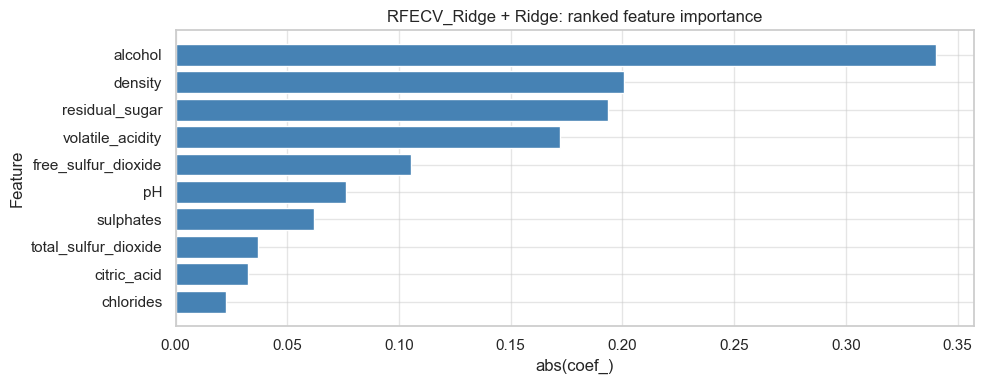

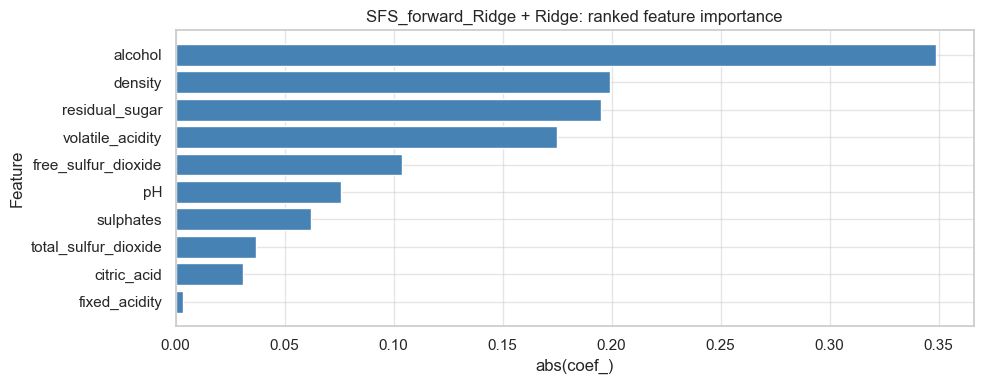

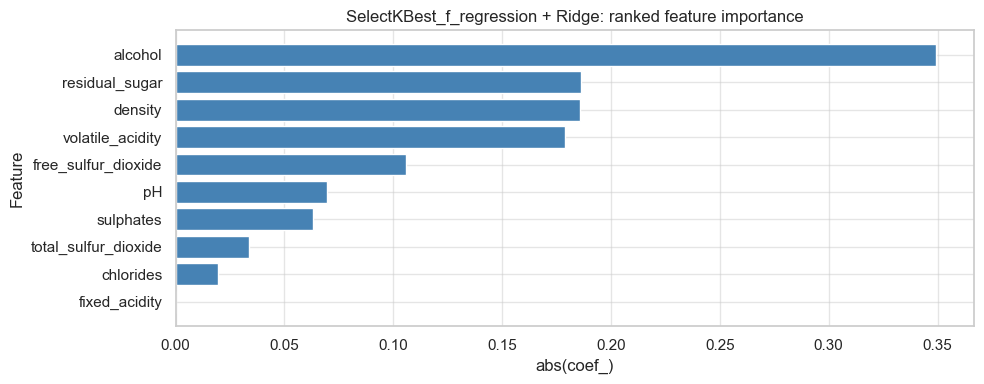

,selector,selected_feature_count,MSE,MAE,R2
0,RFECV_Ridge,10,0.581229,0.589789,0.263891
1,SelectKBest_f_regression,10,0.581293,0.589163,0.263811
2,SFS_forward_Ridge,10,0.581904,0.590736,0.263036


Лучшая процедура отбора признаков: RFECV_Ridge (MSE=0.5812, MAE=0.5898, R2=0.2639)
Выбранные признаки:
['volatile_acidity' 'citric_acid' 'residual_sugar' 'chlorides'
 'free_sulfur_dioxide' 'total_sulfur_dioxide' 'density' 'pH' 'sulphates'
 'alcohol']


,feature,coefficient,abs_coefficient
9,alcohol,0.340337,0.340337
6,density,-0.200581,0.200581
2,residual_sugar,0.193400,0.193400
0,volatile_acidity,-0.172102,0.172102
4,free_sulfur_dioxide,0.105226,0.105226
7,pH,0.076373,0.076373
8,sulphates,0.062138,0.062138
5,total_sulfur_dioxide,-0.036828,0.036828
1,citric_acid,0.032644,0.032644
3,chlorides,-0.022463,0.022463


In [44]:
X_train_stage2 = X_train_num_scaled.copy()
X_test_stage2 = X_test_num_scaled.copy()
stage2_feature_names = np.array(numeric_cols)

ridge_alpha = stage1_reports["Ridge"]["best_params"].get("alpha", 1.0)
n_selected = min(10, len(stage2_feature_names) - 1)

selection_specs = {
    "RFECV_Ridge": RFECV(
        estimator=Ridge(alpha=ridge_alpha),
        step=1,
        cv=CV,
        scoring="r2",
        min_features_to_select=5,
        n_jobs=-1,
    ),
    "SFS_forward_Ridge": SequentialFeatureSelector(
        estimator=Ridge(alpha=ridge_alpha),
        n_features_to_select=n_selected,
        direction="forward",
        scoring="r2",
        cv=5,
        n_jobs=-1,
    ),
    "SelectKBest_f_regression": SelectKBest(
        score_func=f_regression,
        k=n_selected,
    ),
}

selection_reports = {}
selection_results = []

for selector_name, selector in selection_specs.items():
    selector.fit(X_train_stage2, y_train)
    support_mask = selector.get_support()
    selected_features = stage2_feature_names[support_mask]

    X_train_selected = selector.transform(X_train_stage2)
    X_test_selected = selector.transform(X_test_stage2)

    selector_model = Ridge(alpha=ridge_alpha)
    selector_model.fit(X_train_selected, y_train)
    selector_predictions = selector_model.predict(X_test_selected)
    selector_metrics = calculate_metrics(y_test, selector_predictions)

    coef_tbl = coefficient_table(selector_model, selected_features)
    importance_tbl = plot_importance(
        model_name=f"{selector_name} + Ridge",
        model=selector_model,
        X_ref=X_test_selected,
        y_ref=y_test,
        feature_names=selected_features,
        top_n=len(selected_features),
    )

    result_row = {
        "selector": selector_name,
        "selected_feature_count": int(support_mask.sum()),
        "selected_features": list(selected_features),
        **selector_metrics,
    }
    selection_results.append(result_row)
    selection_reports[selector_name] = {
        "selector": selector,
        "model": selector_model,
        "selected_features": selected_features,
        "coef_table": coef_tbl,
        "importance_table": importance_tbl,
    }

selection_results_df = pd.DataFrame(selection_results).sort_values(
    by=["R2", "MSE", "MAE"],
    ascending=[False, True, True],
).reset_index(drop=True)

display(selection_results_df[["selector", "selected_feature_count", "MSE", "MAE", "R2"]])

best_selection = selection_results_df.iloc[0].to_dict()
best_selection_name = best_selection["selector"]
print(
    f"Лучшая процедура отбора признаков: {best_selection_name} "
    f"(MSE={best_selection['MSE']:.4f}, MAE={best_selection['MAE']:.4f}, R2={best_selection['R2']:.4f})"
)
print("Выбранные признаки:")
print(selection_reports[best_selection_name]["selected_features"])
display(selection_reports[best_selection_name]["coef_table"])


## Итоговые выводы

Сформируем итоговые выводы по лучшим моделям первого этапа, второго этапа и по результатам отбора признаков.


In [45]:
best_stage1_row = stage1_results_df.iloc[0]
best_stage2_row = stage2_results_df.iloc[0]
best_selection_row = selection_results_df.iloc[0]

print(
    f"Лучший регрессор без категориальных признаков: {best_stage1_row['model']} "
    f"(MSE={best_stage1_row['MSE']:.4f}, MAE={best_stage1_row['MAE']:.4f}, R2={best_stage1_row['R2']:.4f})."
)
print(
    f"Лучший регрессор второго этапа: {best_stage2_row['model']} "
    f"(MSE={best_stage2_row['MSE']:.4f}, MAE={best_stage2_row['MAE']:.4f}, R2={best_stage2_row['R2']:.4f})."
)
print(
    f"Лучшая процедура отбора признаков: {best_selection_row['selector']} "
    f"(MSE={best_selection_row['MSE']:.4f}, MAE={best_selection_row['MAE']:.4f}, R2={best_selection_row['R2']:.4f})."
)

if best_selection_row["R2"] > best_stage2_row["R2"]:
    print("Отбор признаков улучшил качество относительно лучшей модели второго этапа по метрике R2.")
elif best_selection_row["R2"] < best_stage2_row["R2"]:
    print("Отбор признаков ухудшил качество относительно лучшей модели второго этапа по метрике R2.")
else:
    print("Отбор признаков не изменил качество относительно лучшей модели второго этапа по метрике R2.")

print()
print("Интерпретация результатов:")
print("- На первом этапе модели обучаются на численных признаках после стандартной нормализации.")
print("- На втором этапе используется тот же набор признаков в едином pipeline, потому что исходный датасет не содержит категориальных колонок.")
print("- Итог о полезности отбора признаков делается по сравнению с лучшей моделью второго этапа.")


Лучший регрессор без категориальных признаков: KNeighborsRegressor (MSE=0.5337, MAE=0.5656, R2=0.3241).
Лучший регрессор второго этапа: KNeighborsRegressor (MSE=0.5337, MAE=0.5656, R2=0.3241).
Лучшая процедура отбора признаков: RFECV_Ridge (MSE=0.5812, MAE=0.5898, R2=0.2639).
Отбор признаков ухудшил качество относительно лучшей модели второго этапа по метрике R2.

Интерпретация результатов:
- На первом этапе модели обучаются на численных признаках после стандартной нормализации.
- На втором этапе используется тот же набор признаков в едином pipeline, потому что исходный датасет не содержит категориальных колонок.
- Итог о полезности отбора признаков делается по сравнению с лучшей моделью второго этапа.
